# Section 4.7

## Example 4.7.1

In [ ]:
g(x) = [
    sin(x[1] + x[2]), 
    cos(x[1] - x[2]), 
    exp(x[1] - x[2])
]
p = [1, 1];
f(x) = g(x) - g(p)

In [ ]:
using FNCFunctions, LinearAlgebra

x = FNC.levenberg(f, [0, 0])

In [ ]:
f.(x)

In [ ]:
using Plots, Printf, LaTeXStrings

plt = plot(xlabel="iteration", yaxis=(:log10, "error"),
    title="Convergence of Gauss–Newton")
for R in [1e-4, 1e-3, 1e-2, 1e-1]
    # Define the perturbed function.
    f(x) = g(x) - g(p) + R * normalize([-1, 1, -1])
    x = FNC.levenberg(f, [0, 0])
    r = x[end]
    err = [norm(x - r) for x in x[1:end-1]]
    normres = norm(f(r))
    plot!(err, label=latexstring(@sprintf("||f||=%.2g", normres)))
end
plt

## Example 4.7.2

$$
w(s) = \frac{V s}{K_m + s}
$$

In [1]:
m = 25;
s = range(0.05, 6, m)
w_exact = @. 2s / (0.5 + s)                           # exactly on the curve

25-element Vector{Float64}:
 0.18181818181818182
 0.7467362924281984
 1.0438247011952189
 1.2270531400966183
 1.3513513513513513
 1.441210710128056
 1.50920245398773
 1.5624430264357336
 1.6052631578947367
 1.6404494382022472
 1.669876203576341
 1.694850603941513
 1.7163120567375887
 1.7349530646051905
 1.7512953367875648
 1.7657393850658858
 1.7785977859778597
 1.790118058592042
 1.800498753117207
 1.80990099009901
 1.8184568835098336
 1.8262757871878392
 1.8334489937543372
 1.8400533155614796
 1.8461538461538463

In [2]:
using Random
Random.seed!(19716)
w = w_exact + 0.05 * randn(m);

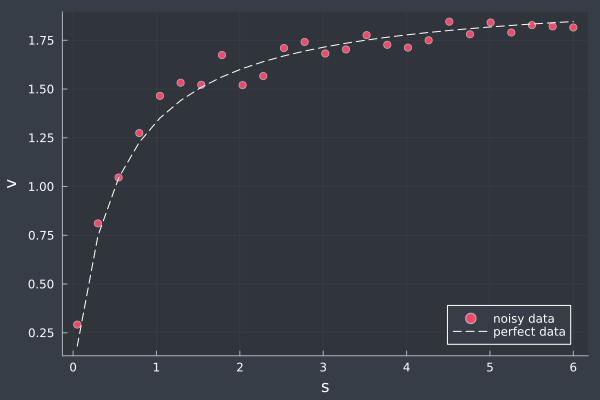

In [3]:
using Plots
theme(:dark)
scatter(s, w, label="noisy data", xlabel="s", ylabel="v", leg=:bottomright)
plot!(s, w_exact, l=:dash, color=:white, label="perfect data")

In [4]:
function misfit(x)
    V, Km = x   # rename components for clarity
    return @. V * s / (Km + s) - w
end;

In [5]:
function misfitjac(x)
    V, Km = x   # rename components for clarity
    J = zeros(m, 2)
    J[:, 1] = @. s / (Km + s)                # ∂w/∂V
    J[:, 2] = @. -V * s / (Km + s)^2         # ∂w/∂Km
    return J
end;

In [6]:
using FNCFunctions
x₁ = [1, .1]
x = FNC.newtonsys(misfit, misfitjac, x₁)

10-element Vector{Vector{Float64}}:
 [1.0, 0.1]
 [1.8414394815100863, 0.35251878615016696]
 [1.9411527336880052, 0.403541787602494]
 [1.9431169270432649, 0.40520730807959787]
 [1.9431326437765857, 0.40523152519981354]
 [1.9431328512301316, 0.4052318495627848]
 [1.9431328540046637, 0.40523185389975774]
 [1.9431328540417605, 0.40523185395774497]
 [1.9431328540422563, 0.40523185395852007]
 [1.943132854042263, 0.40523185395853056]

In [7]:
V, Km = x[end]  # final values

2-element Vector{Float64}:
 1.943132854042263
 0.40523185395853056

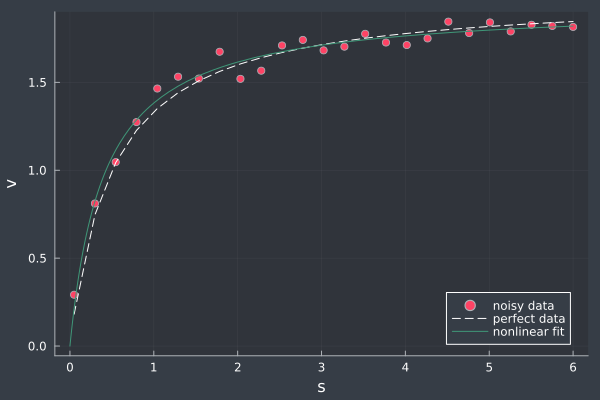

In [8]:
model(s) = V * s / (Km + s)
plot!(model, 0, 6, label="nonlinear fit")

$$
w = \frac{V s}{K_m + s}
$$


$$
\frac{1}{w} = \frac{K_m + s}{Vs} = \frac{K_m}{Vs} + \frac{1}{V}
$$

$$
\frac{1}{w} = \alpha \cdot s^{-1} + \beta
$$


$$f_i([\alpha,\beta]) = \left(\alpha \cdot \frac{1}{s_i} + \beta\right) - \frac{1}{w_i}$$

In [9]:
A = [s .^ (-1) s .^ 0]
u = 1 ./ w
α, β = A \ u

2-element Vector{Float64}:
 0.1457937477053463
 0.552131950723048

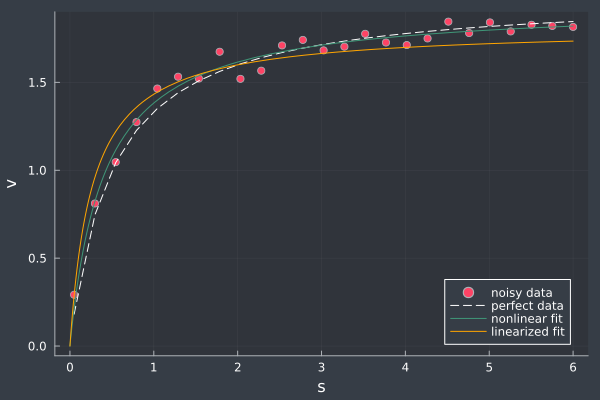

In [10]:
linmodel(x) = 1 / (β + α / x)
plot!(linmodel, 0, 6, color=:orange, label="linearized fit")